In [1]:
# 데이터 처리를 위한 pandas와 numpy를 불러옵니다.
import pandas as pd
import numpy as np

# 그래프를 그리기 위한 matplotlib와 seaborn을 불러옵니다.
import matplotlib.pyplot as plt
import seaborn as sns

# 파일과 폴더를 확인하기 위해 os를 불러옵니다.
import os

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 결과 저장 폴더 생성
os.makedirs("../images", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)


In [2]:
# 공통 전처리 데이터
violation_file = "../data/processed/violation_2017_2023.csv"

# 05에서 만든 동별 민원/CCTV/상습 발생지 데이터
support_file = "../data/processed/dong_support_summary.csv"

# 2020 불법주차 좌표 데이터
parking_2020_file = "../data/대구광역시 북구_데이터통합플랫폼_불법주차_20201005.csv"

# 04에서 만든 장소 TOP10 요약 데이터
location_top10_file = "../data/processed/location_top10_summary.csv"

# 파일을 불러옵니다.
violation = pd.read_csv(
    violation_file,
    encoding="utf-8-sig",
    parse_dates=["위반일자"]
)

support = pd.read_csv(
    support_file,
    encoding="utf-8-sig"
)

parking_2020 = pd.read_csv(
    parking_2020_file,
    encoding="utf-8"
)

print("2017~2023 단속 데이터:", violation.shape)
print("동별 지원 데이터:", support.shape)
print("2020 좌표 데이터:", parking_2020.shape)

# 04 분석 결과가 있으면 함께 불러옵니다.
if os.path.exists(location_top10_file):
    location_top10 = pd.read_csv(location_top10_file, encoding="utf-8-sig")
    print("장소 TOP10 요약:", location_top10.shape)
else:
    location_top10 = None
    print("※ location_top10_summary.csv가 없습니다. 04_location_analysis.ipynb를 먼저 실행하세요.")


2017~2023 단속 데이터: (681828, 10)
동별 지원 데이터: (26, 6)
2020 좌표 데이터: (67949, 5)
장소 TOP10 요약: (10, 6)


In [3]:
# 위반장소 앞뒤 공백을 정리합니다.
violation["위반장소_정리"] = violation["위반장소"].astype(str).str.strip()
violation["위반장소_정리"] = violation["위반장소_정리"].str.replace(r"\s+", " ", regex=True)

# 장소명에서 동 이름을 추출합니다.
dong_extract = violation["위반장소_정리"].str.extract(
    r"([가-힣]+?)\d*(동)(?:\d가)?"
)

violation["동"] = dong_extract[0] + dong_extract[1]

# 추출 결과 확인
matched = violation["동"].notnull().sum()
total = len(violation)
coverage = matched / total * 100

print("전체 단속 건수:", f"{total:,}")
print("동 이름 추출 성공:", f"{matched:,}")
print("동 추출 가능 비율:", f"{coverage:.1f}%")
print()
print("추출된 동 상위 20개")
print(violation["동"].value_counts().head(20))


전체 단속 건수: 681,828
동 이름 추출 성공: 450,683
동 추출 가능 비율: 66.1%

추출된 동 상위 20개
동
동천동    66091
산격동    52648
태전동    36495
침산동    35722
칠성동    28339
복현동    23681
읍내동    22792
관음동    20653
구암동    20431
서변동    19383
학정동    17132
고성동    15528
사수동    13577
노원동    13495
대현동    12122
매천동     8596
새동      8049
동변동     7273
연경동     6854
팔달동     4273
Name: count, dtype: int64


In [4]:
# 동을 추출할 수 있는 데이터만 사용합니다.
v = violation.dropna(subset=["동"]).copy()

# 동별 전체 단속 건수
violation_by_dong = (
    v.groupby("동")
    .size()
    .rename("단속건수_2017_2023")
)

# 동 × 시간 교차표
dong_hour = pd.crosstab(v["동"], v["시간"]).reindex(columns=range(24), fill_value=0)

# 동별 집중 시간
peak_hour = dong_hour.idxmax(axis=1).rename("집중시간")
peak_hour_count = dong_hour.max(axis=1).rename("집중시간건수")

# 동별 집중시간 비중
hour_concentration = (
    peak_hour_count / violation_by_dong * 100
).round(1).rename("집중시간비중")

# 동 × 요일 교차표
weekday_order = [
    "월요일", "화요일", "수요일", "목요일",
    "금요일", "토요일", "일요일"
]

dong_weekday = pd.crosstab(v["동"], v["요일"]).reindex(
    columns=weekday_order,
    fill_value=0
)

# 동별 집중 요일
peak_weekday = dong_weekday.idxmax(axis=1).rename("집중요일")
peak_weekday_count = dong_weekday.max(axis=1).rename("집중요일건수")

# 동별 요일 집중 비중
weekday_concentration = (
    peak_weekday_count / violation_by_dong * 100
).round(1).rename("집중요일비중")

# 한 표로 합칩니다.
violation_dong_summary = pd.concat(
    [
        violation_by_dong,
        peak_hour,
        peak_hour_count,
        hour_concentration,
        peak_weekday,
        peak_weekday_count,
        weekday_concentration
    ],
    axis=1
).reset_index()

display(violation_dong_summary.head(20))


,동,단속건수_2017_2023,집중시간,집중시간건수,집중시간비중,집중요일,집중요일건수,집중요일비중
0,가동,1,8,1,100.0,목요일,1,100.0
1,검단동,4064,15,568,14.0,목요일,963,23.7
2,검당동,1,15,1,100.0,목요일,1,100.0
3,겸단동,1,7,1,100.0,금요일,1,100.0
4,경대동,2,14,2,100.0,수요일,2,100.0
5,경동,5,17,3,60.0,수요일,3,60.0
6,경북대학교동,7,16,4,57.1,월요일,2,28.6
7,고서어동,1,7,1,100.0,목요일,1,100.0
8,고성동,15528,14,3607,23.2,월요일,3300,21.3
9,관움동,1,21,1,100.0,화요일,1,100.0


In [5]:
# 2020 데이터의 컬럼을 확인합니다.
print(parking_2020.columns.tolist())

# 행정동별 평균 좌표를 대표 좌표로 사용합니다.
dong_coord = (
    parking_2020.groupby("행정동", as_index=False)
    .agg(
        대표위도=("위도", "mean"),
        대표경도=("경도", "mean")
    )
    .rename(columns={"행정동": "동"})
)

display(dong_coord.head())


['경도', '위도', '행정동', '위반상태', '기준일자']


,동,대표위도,대표경도
0,검단동,35.913265,128.622055
1,고성동,35.881457,128.584430
2,관문동,35.901432,128.534717
3,관음동,35.940417,128.545319
4,구암동,35.932598,128.561487


In [6]:
# 단속 분석 결과와 05의 지원 데이터를 합칩니다.
final = violation_dong_summary.merge(
    support,
    on="동",
    how="outer"
)

# 지도 표시용 대표 좌표를 붙입니다.
final = final.merge(
    dong_coord,
    on="동",
    how="left"
)

# 수치형 결측치는 0으로 채웁니다.
zero_cols = [
    "단속건수_2017_2023",
    "집중시간건수",
    "집중시간비중",
    "집중요일건수",
    "집중요일비중",
    "민원건수_2018_2021",
    "CCTV수",
    "주정차단속CCTV수",
    "상습발생지수",
    "상습지역민원누적"
]

for col in zero_cols:
    if col in final.columns:
        final[col] = final[col].fillna(0)

# 단속이 하나도 없는 동은 집중시간/요일을 '자료없음'으로 표시합니다.
final["집중시간"] = final["집중시간"].fillna(-1).astype(int)
final["집중요일"] = final["집중요일"].fillna("자료없음")

# 단속건수 기준으로 정렬합니다.
final = final.sort_values(
    "단속건수_2017_2023",
    ascending=False
).reset_index(drop=True)

display(final.head(20))


,동,단속건수_2017_2023,집중시간,집중시간건수,집중시간비중,집중요일,집중요일건수,집중요일비중,민원건수_2018_2021,CCTV수,주정차단속CCTV수,상습발생지수,상습지역민원누적,대표위도,대표경도
0,동천동,66091.0,15,14572.0,22.0,월요일,11659.0,17.6,8869.0,44.0,6.0,3.0,1249.0,35.939396,128.558542
1,산격동,52648.0,15,8039.0,15.3,수요일,9026.0,17.1,10961.0,80.0,12.0,5.0,793.0,NaN,NaN
2,태전동,36495.0,15,5485.0,15.0,월요일,7069.0,19.4,6098.0,78.0,9.0,1.0,289.0,NaN,NaN
3,침산동,35722.0,14,4915.0,13.8,월요일,6663.0,18.7,5297.0,51.0,6.0,0.0,0.0,NaN,NaN
4,칠성동,28339.0,15,5192.0,18.3,수요일,5343.0,18.9,3847.0,45.0,12.0,0.0,0.0,35.878536,128.597066
5,복현동,23681.0,15,3224.0,13.6,목요일,5111.0,21.6,7303.0,52.0,4.0,2.0,2084.0,NaN,NaN
6,읍내동,22792.0,15,4681.0,20.5,수요일,4622.0,20.3,4217.0,61.0,3.0,1.0,211.0,35.943041,128.551989
7,관음동,20653.0,15,3887.0,18.8,화요일,4017.0,19.4,4924.0,34.0,2.0,0.0,0.0,35.940417,128.545319
8,구암동,20431.0,7,4003.0,19.6,월요일,4104.0,20.1,6635.0,63.0,5.0,3.0,1114.0,35.932598,128.561487
9,서변동,19383.0,8,2991.0,15.4,금요일,4883.0,25.2,3592.0,26.0,4.0,2.0,816.0,NaN,NaN


In [7]:
# 상대 순위를 0~1 범위로 계산하는 함수입니다.
def percentile_score(series):
    return series.rank(pct=True, method="average")

# 단속 발생량 점수 (40점)
final["단속점수"] = (
    percentile_score(final["단속건수_2017_2023"]) * 40
)

# 민원 발생량 점수 (25점)
final["민원점수"] = (
    percentile_score(final["민원건수_2018_2021"]) * 25
)

# 특정 시간 집중도 점수 (20점)
final["시간집중점수"] = (
    percentile_score(final["집중시간비중"]) * 20
)

# CCTV는 적을수록 부족도 점수가 높게 계산되도록 반대로 순위를 적용합니다.
cctv_rank = percentile_score(final["주정차단속CCTV수"])
final["CCTV부족점수"] = (1 - cctv_rank) * 15

# 전체 관리 우선도 점수
final["관리점수"] = (
    final["단속점수"]
    + final["민원점수"]
    + final["시간집중점수"]
    + final["CCTV부족점수"]
).round(1)

display(
    final[
        [
            "동", "단속점수", "민원점수",
            "시간집중점수", "CCTV부족점수", "관리점수"
        ]
    ].sort_values("관리점수", ascending=False)
)


,동,단속점수,민원점수,시간집중점수,CCTV부족점수,관리점수
0,동천동,40.00,24.8,3.36,0.42,68.6
22,동호동,32.96,20.8,5.36,8.64,67.8
10,학정동,36.80,22.6,5.76,1.62,66.8
1,산격동,39.68,25.0,1.60,0.06,66.3
20,국우동,33.60,21.6,2.08,8.64,65.9
...,...,...,...,...,...,...
120,테전동,7.84,10.0,15.76,8.64,42.2
121,한라아파트동,7.84,10.0,15.76,8.64,42.2
122,태정동,7.84,10.0,15.76,8.64,42.2
123,학전동,7.84,10.0,15.76,8.64,42.2


In [9]:
# 관리등급 · 관리유형 지정
# 등급 기준
# - A등급: 80점 이상
# - B등급: 60점 이상 80점 미만
# - C등급: 40점 이상 60점 미만
# - D등급: 40점 미만
# 추가로 A·B 등급 지역은 CCTV 수준과 집중시간을 참고하여 관리유형을 부여합니다.

In [10]:
# 관리등급 함수
def make_grade(score):
    if score >= 80:
        return "A"
    elif score >= 60:
        return "B"
    elif score >= 40:
        return "C"
    else:
        return "D"

final["관리등급"] = final["관리점수"].apply(make_grade)

# 주정차단속 CCTV 중앙값을 기준으로 상대적으로 많고 적음을 구분합니다.
cctv_median = final["주정차단속CCTV수"].median()

def management_type(row):
    if row["관리등급"] == "A":
        if row["주정차단속CCTV수"] <= cctv_median:
            return "CCTV 보강·집중단속 검토"
        else:
            return "집중시간대 단속 강화 검토"
    elif row["관리등급"] == "B":
        return "관리 강화 검토"
    elif row["관리등급"] == "C":
        return "일반 관리"
    else:
        return "상대적 우선도 낮음"

final["관리유형"] = final.apply(management_type, axis=1)

# 집중시간 문구 생성
def peak_hour_text(hour):
    if hour < 0:
        return "자료없음"
    return f"{int(hour)}시"

final["집중시간표시"] = final["집중시간"].apply(peak_hour_text)

display(
    final[
        [
            "동", "관리점수", "관리등급", "관리유형",
            "단속건수_2017_2023", "민원건수_2018_2021",
            "주정차단속CCTV수", "집중요일", "집중시간표시"
        ]
    ].sort_values("관리점수", ascending=False)
)


,동,관리점수,관리등급,관리유형,단속건수_2017_2023,민원건수_2018_2021,주정차단속CCTV수,집중요일,집중시간표시
0,동천동,68.6,B,관리 강화 검토,66091.0,8869.0,6.0,월요일,15시
22,동호동,67.8,B,관리 강화 검토,2668.0,240.0,0.0,화요일,11시
10,학정동,66.8,B,관리 강화 검토,17132.0,2002.0,2.0,월요일,11시
1,산격동,66.3,B,관리 강화 검토,52648.0,10961.0,12.0,수요일,15시
20,국우동,65.9,B,관리 강화 검토,4207.0,1049.0,0.0,목요일,7시
...,...,...,...,...,...,...,...,...,...
120,테전동,42.2,C,일반 관리,1.0,0.0,0.0,화요일,8시
121,한라아파트동,42.2,C,일반 관리,1.0,0.0,0.0,일요일,10시
122,태정동,42.2,C,일반 관리,1.0,0.0,0.0,목요일,11시
123,학전동,42.2,C,일반 관리,1.0,0.0,0.0,수요일,9시


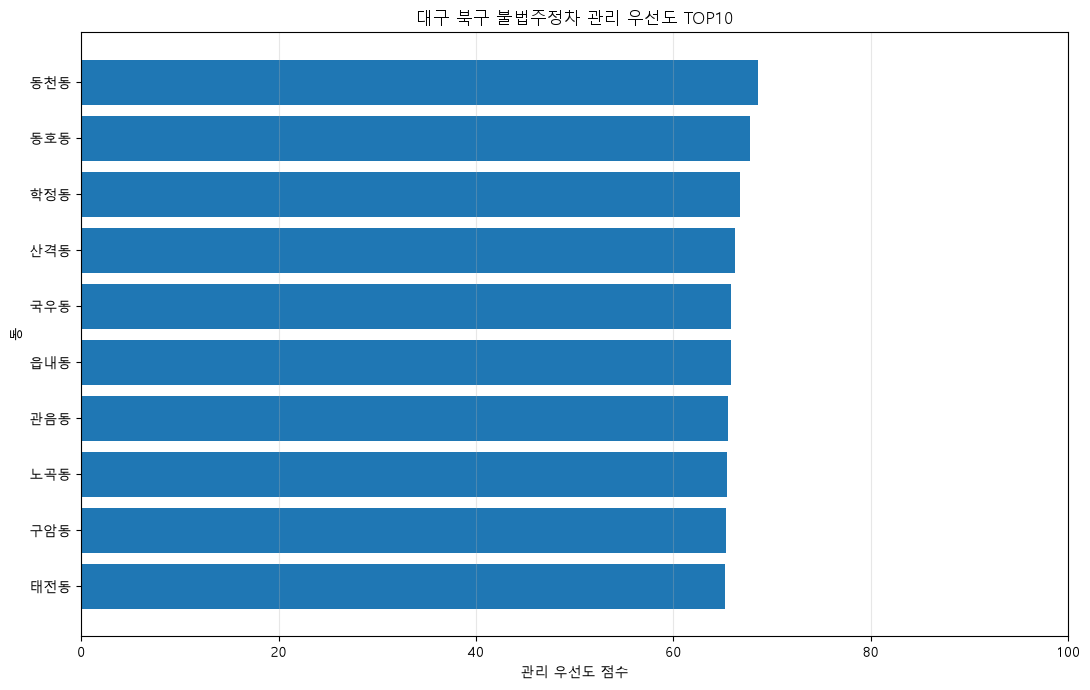

In [11]:
# 관리점수 상위 10개 동을 선택합니다.
priority_top10 = (
    final.sort_values("관리점수", ascending=False)
    .head(10)
)

plt.figure(figsize=(11, 7))
plt.barh(
    priority_top10["동"],
    priority_top10["관리점수"]
)
plt.gca().invert_yaxis()

plt.title("대구 북구 불법주정차 관리 우선도 TOP10")
plt.xlabel("관리 우선도 점수")
plt.ylabel("동")
plt.xlim(0, 100)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig("../images/final_priority_top10.png", dpi=150, bbox_inches="tight")
plt.show()


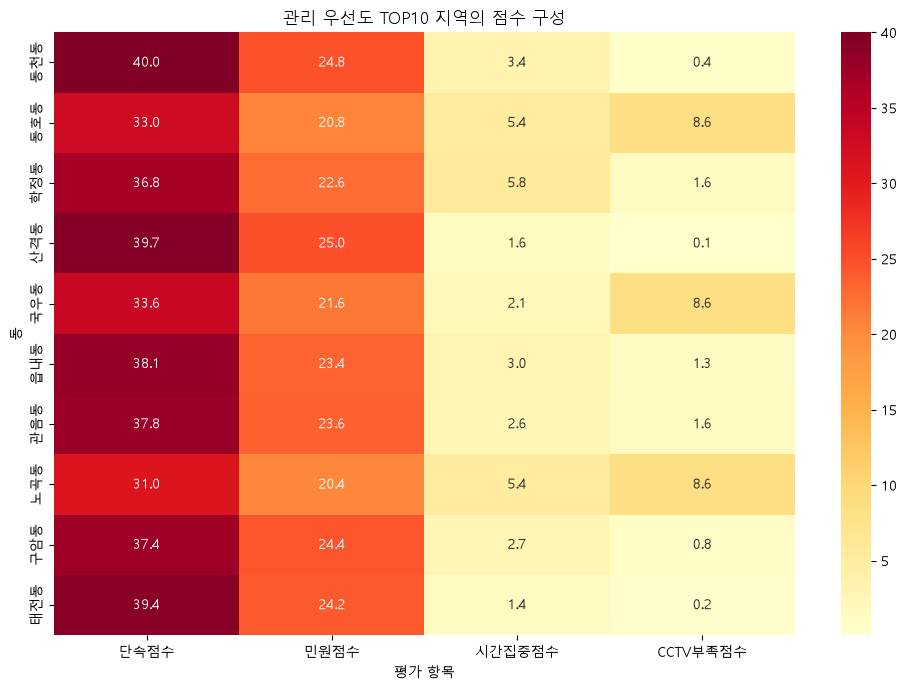

In [12]:
# 상위 10개 지역의 점수 구성요소를 확인합니다.
score_cols = [
    "단속점수",
    "민원점수",
    "시간집중점수",
    "CCTV부족점수"
]

score_heatmap = priority_top10.set_index("동")[score_cols]

plt.figure(figsize=(10, 7))
sns.heatmap(
    score_heatmap,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("관리 우선도 TOP10 지역의 점수 구성")
plt.xlabel("평가 항목")
plt.ylabel("동")
plt.tight_layout()

plt.savefig("../images/final_priority_score_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


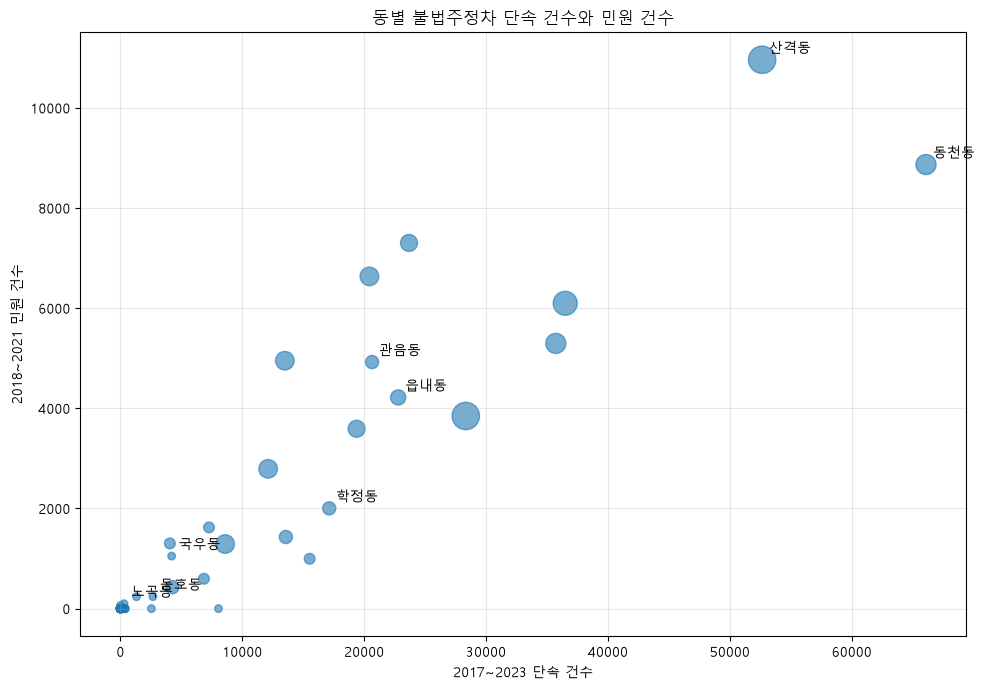

In [13]:
plt.figure(figsize=(10, 7))

bubble_size = final["주정차단속CCTV수"] * 30 + 30

plt.scatter(
    final["단속건수_2017_2023"],
    final["민원건수_2018_2021"],
    s=bubble_size,
    alpha=0.6
)

# 관리점수 상위 8개 동만 이름 표시
for _, row in final.sort_values("관리점수", ascending=False).head(8).iterrows():
    plt.annotate(
        row["동"],
        (row["단속건수_2017_2023"], row["민원건수_2018_2021"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("동별 불법주정차 단속 건수와 민원 건수")
plt.xlabel("2017~2023 단속 건수")
plt.ylabel("2018~2021 민원 건수")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("../images/final_violation_complaint_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


In [14]:
# 전체 연도, 월, 요일, 시간 집계
year_count = violation.groupby("연도").size()
month_count = violation.groupby("월").size().reindex(range(1, 13))
weekday_order = [
    "월요일", "화요일", "수요일", "목요일",
    "금요일", "토요일", "일요일"
]
weekday_count = violation.groupby("요일").size().reindex(weekday_order)
hour_count = violation.groupby("시간").size().reindex(range(24), fill_value=0)

overall_summary = pd.DataFrame([{
    "전체단속건수": len(violation),
    "분석시작일": violation["위반일자"].min().date(),
    "분석종료일": violation["위반일자"].max().date(),
    "최다연도": int(year_count.idxmax()),
    "최다월": int(month_count.idxmax()),
    "최다요일": weekday_count.idxmax(),
    "최다시간": int(hour_count.idxmax()),
    "최다시간건수": int(hour_count.max()),
    "동추출가능비율": round(coverage, 1)
}])

# 04 결과가 있으면 TOP1 장소도 추가합니다.
if location_top10 is not None and len(location_top10) > 0:
    overall_summary["최다단속장소"] = location_top10.iloc[0]["위반장소"]
    overall_summary["최다단속장소건수"] = int(location_top10.iloc[0]["총단속건수"])

display(overall_summary)



,전체단속건수,분석시작일,분석종료일,최다연도,최다월,최다요일,최다시간,최다시간건수,동추출가능비율,최다단속장소,최다단속장소건수
0,681828,2017-01-01,2023-12-31,2023,11,월요일,15,114933,66.1,동아아울렛 뒤편,17189


In [15]:
# 전체 연도, 월, 요일, 시간 집계
year_count = violation.groupby("연도").size()
month_count = violation.groupby("월").size().reindex(range(1, 13))
weekday_order = [
    "월요일", "화요일", "수요일", "목요일",
    "금요일", "토요일", "일요일"
]
weekday_count = violation.groupby("요일").size().reindex(weekday_order)
hour_count = violation.groupby("시간").size().reindex(range(24), fill_value=0)

overall_summary = pd.DataFrame([{
    "전체단속건수": len(violation),
    "분석시작일": violation["위반일자"].min().date(),
    "분석종료일": violation["위반일자"].max().date(),
    "최다연도": int(year_count.idxmax()),
    "최다월": int(month_count.idxmax()),
    "최다요일": weekday_count.idxmax(),
    "최다시간": int(hour_count.idxmax()),
    "최다시간건수": int(hour_count.max()),
    "동추출가능비율": round(coverage, 1)
}])

# 04 결과가 있으면 TOP1 장소도 추가합니다.
if location_top10 is not None and len(location_top10) > 0:
    overall_summary["최다단속장소"] = location_top10.iloc[0]["위반장소"]
    overall_summary["최다단속장소건수"] = int(location_top10.iloc[0]["총단속건수"])

display(overall_summary)


,전체단속건수,분석시작일,분석종료일,최다연도,최다월,최다요일,최다시간,최다시간건수,동추출가능비율,최다단속장소,최다단속장소건수
0,681828,2017-01-01,2023-12-31,2023,11,월요일,15,114933,66.1,동아아울렛 뒤편,17189


In [16]:
# 웹에서 사용할 컬럼을 정리합니다.
dashboard_cols = [
    "동",
    "대표위도",
    "대표경도",
    "단속건수_2017_2023",
    "민원건수_2018_2021",
    "CCTV수",
    "주정차단속CCTV수",
    "상습발생지수",
    "상습지역민원누적",
    "집중요일",
    "집중요일비중",
    "집중시간",
    "집중시간비중",
    "관리점수",
    "관리등급",
    "관리유형"
]

dashboard_region = final[dashboard_cols].copy()

# 관리점수 순으로 정렬합니다.
dashboard_region = dashboard_region.sort_values(
    "관리점수",
    ascending=False
).reset_index(drop=True)

# 저장
region_path = "../data/processed/final_region_summary.csv"
overall_path = "../data/processed/final_overall_summary.csv"

dashboard_region.to_csv(
    region_path,
    index=False,
    encoding="utf-8-sig"
)

overall_summary.to_csv(
    overall_path,
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", region_path)
print("저장 완료:", overall_path)


저장 완료: ../data/processed/final_region_summary.csv
저장 완료: ../data/processed/final_overall_summary.csv


In [17]:
# 관리 우선도 상위 지역을 최종 확인합니다.
final_view = dashboard_region.head(10).copy()

display(final_view)

print("관리 우선도 1위:", final_view.iloc[0]["동"])
print("관리점수:", final_view.iloc[0]["관리점수"])
print("등급:", final_view.iloc[0]["관리등급"])
print("집중요일:", final_view.iloc[0]["집중요일"])
print("집중시간:", int(final_view.iloc[0]["집중시간"]), "시")
print("관리유형:", final_view.iloc[0]["관리유형"])


,동,대표위도,대표경도,단속건수_2017_2023,민원건수_2018_2021,CCTV수,주정차단속CCTV수,상습발생지수,상습지역민원누적,집중요일,집중요일비중,집중시간,집중시간비중,관리점수,관리등급,관리유형
0,동천동,35.939396,128.558542,66091.0,8869.0,44.0,6.0,3.0,1249.0,월요일,17.6,15,22.0,68.6,B,관리 강화 검토
1,동호동,NaN,NaN,2668.0,240.0,0.0,0.0,0.0,0.0,화요일,21.3,11,31.4,67.8,B,관리 강화 검토
2,학정동,NaN,NaN,17132.0,2002.0,24.0,2.0,1.0,64.0,월요일,24.2,11,31.8,66.8,B,관리 강화 검토
3,산격동,NaN,NaN,52648.0,10961.0,80.0,12.0,5.0,793.0,수요일,17.1,15,15.3,66.3,B,관리 강화 검토
4,국우동,35.949053,128.570808,4207.0,1049.0,16.0,0.0,0.0,0.0,목요일,22.4,7,16.8,65.9,B,관리 강화 검토
5,읍내동,35.943041,128.551989,22792.0,4217.0,61.0,3.0,1.0,211.0,수요일,20.3,15,20.5,65.8,B,관리 강화 검토
6,관음동,35.940417,128.545319,20653.0,4924.0,34.0,2.0,0.0,0.0,화요일,19.4,15,18.8,65.5,B,관리 강화 검토
7,노곡동,NaN,NaN,296.0,98.0,0.0,0.0,0.0,0.0,월요일,17.6,12,31.4,65.4,B,관리 강화 검토
8,구암동,35.932598,128.561487,20431.0,6635.0,63.0,5.0,3.0,1114.0,월요일,20.1,7,19.6,65.3,B,관리 강화 검토
9,태전동,NaN,NaN,36495.0,6098.0,78.0,9.0,1.0,289.0,월요일,19.4,15,15.0,65.2,B,관리 강화 검토


관리 우선도 1위: 동천동
관리점수: 68.6
등급: B
집중요일: 월요일
집중시간: 15 시
관리유형: 관리 강화 검토
